In [1]:
# Test script 2

In [1]:
# Test calculating pop weighted AF for ozone

In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# === Path config ===
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
O3_DIR = "/glade/work/awells/air_quality/CESM/ozone/OSDMA8_BC/"

In [3]:
# === Load data ===
pop_file = "ssp2_coarse_grid_annual_2000-2100.nc"
pop_path = os.path.join(POP_DIR, pop_file)
population = xr.open_dataarray(pop_path)

In [4]:
# === Path config ===
MASK_DIR = "/glade/work/awells/air_quality/BMR/masks/country/"

in_file = "GBD_Country_Masks_0.10.nc"
in_path = os.path.join(MASK_DIR, in_file)
country_mask = xr.open_dataarray(in_path)

In [5]:
o3_file = "OSDMA8_BC_CESM2_ARISE_01_2035-2068.nc"
o3_path = os.path.join(O3_DIR, o3_file)
o3 = xr.open_dataarray(o3_path)

# Adjust indices to match (with small tolerance)
# e.g., max 1e-7 km distance
o3 = o3.reindex_like(country_mask, method="nearest", tolerance=1e-9, fill_value=0)
population = population.reindex_like(country_mask, method="nearest", tolerance=1e-9)

In [6]:
n_samples = 1000

# === Scalar distributions (assuming normal dist.) ===
# TMREL from GBD21
tmrel_mean = 32.4
tmrel_std = (35.7 - 29.1) / (2 * 1.96)
tmrel_samples = np.random.normal(tmrel_mean, tmrel_std, size=n_samples)

# Wrap in xarray for nice labeling:
tmrel_samples = xr.DataArray(
    tmrel_samples,
    dims=("sample"),
    coords={"sample": np.arange(n_samples)}
)

# Beta from RR per 10ppb
RR_10 = 1.074
RR_10_lower = 1.014
RR_10_upper = 1.137
beta_mean = np.log(RR_10) / 10
beta_std = (np.log(RR_10_upper) - np.log(RR_10_lower)) / (2 * 1.96 * 10)
beta_samples = np.random.normal(beta_mean, beta_std, size=n_samples)

# Wrap in xarray for nice labeling:
beta_samples = xr.DataArray(
    beta_samples,
    dims=("sample"),
    coords={"sample": np.arange(n_samples)}
)

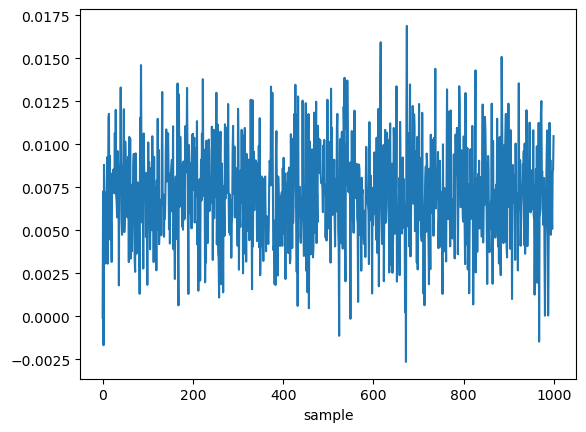

In [9]:
beta_samples.plot()

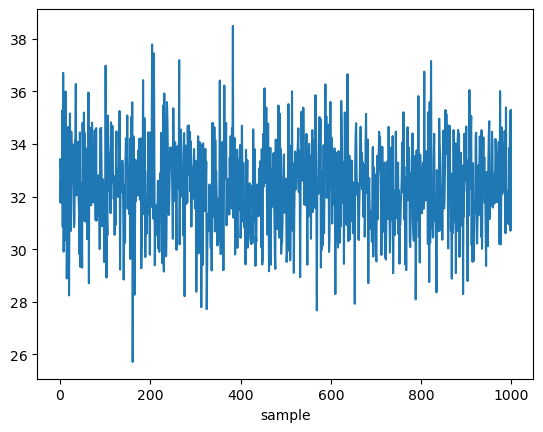

In [8]:
tmrel_samples.plot()

In [10]:
O3_diff = o3.chunk({"lat": 18, "lon": 36}) - tmrel_samples

In [11]:
TMREL_O3 = xr.where(O3_diff > 0, O3_diff, 0)  # where the difference < 0 set to 0

In [12]:
RR = np.exp(beta_samples * TMREL_O3)

In [13]:
AF = (RR-1)/RR

In [14]:
pop_years = population.sel(year=RR.year).chunk({"lat": 18, "lon": 36})

In [15]:
weighted_value = pop_years * AF

In [16]:
country_list = []

for i in range(204):
    mask = country_mask.isel(country=i)
    country_weight = xr.where(mask == 1, weighted_value, np.nan).sum(dim=("lat", "lon"))
    pop_country = xr.where(mask == 1, pop_years, np.nan).sum(dim=("lat", "lon"))
    country_pop_weighted = country_weight / pop_country
    country_list.append(country_pop_weighted)

In [18]:
PAF = xr.concat(country_list, "country")

In [20]:
PAF.to_netcdf("/glade/work/awells/test.nc")


KeyboardInterrupt



In [19]:
paf_save = PAF.load()


KeyboardInterrupt



In [30]:
test = PAF[100,0,:].data

In [32]:
test.compute() # 1331 seconds

array([-0.00216793,  0.19226413, -0.04901119,  0.22481137,  0.18688206,
        0.11367133,  0.08909941,  0.13895642,  0.20183085,  0.16501017,
        0.22751652,  0.090123  ,  0.17035826,  0.28165591,  0.29026878,
        0.14162974,  0.24831662,  0.11869733,  0.12823409,  0.13849182,
        0.09893443,  0.21191607,  0.17651766,  0.21739829,  0.2265867 ,
        0.20411931,  0.18355284,  0.26331979,  0.17794412,  0.28590854,
        0.1854664 ,  0.18307147,  0.15918062,  0.22921122,  0.20698798,
        0.19577989,  0.051158  ,  0.20729211,  0.19403913,  0.23033694,
        0.30261214,  0.21458238,  0.15290718,  0.13819781,  0.17384839,
        0.24220764,  0.23970811,  0.29202201,  0.13721948,  0.16466449,
        0.23506404,  0.22176946,  0.21777324,  0.14632745,  0.21938298,
        0.14277783,  0.23869228,  0.23362329,  0.08622506,  0.24816914,
        0.14960794,  0.26101258,  0.09343508,  0.1472861 ,  0.21998736,
        0.09561909,  0.17531287,  0.16352096,  0.22392829,  0.24